### Import libraries

In [1]:
import os, re, json, math, string
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import emoji
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing Post DataFrame </div>

In [3]:
POSTS_CSV = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_posts.csv"
if not Path(POSTS_CSV).exists():
    alt = Path("data/clean/clean_posts.csv")
    if alt.exists():
        POSTS_CSV = str(alt)

posts_df = pd.read_csv(POSTS_CSV)
if 'timestamp' in posts_df.columns:
    posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'], errors='coerce')
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


In [4]:
# Type of each column
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
posts_df.dtypes   

post_id                        int64
timestamp        datetime64[ns, UTC]
postUser                      object
caption                       object
hashtags                      object
likesCount                     int64
commentsCount                  int64
dtype: object

In [6]:
# Drop columns hashtags
if 'hashtags' in posts_df.columns:
    posts_df = posts_df.drop(columns=['hashtags'])
posts_df.isnull().sum()

post_id          0
timestamp        0
postUser         0
caption          0
likesCount       0
commentsCount    0
dtype: int64

### "Caption" column 

In [5]:
# === Extract CAPTION to  3 columns: caption_text, hashtags, mentions ===

def extract_hashtags(text: str) -> list:
    if pd.isna(text) or not isinstance(text, str):
        return []
    
    # Regex: Tìm tất cả từ bắt đầu bằng #
    hashtags = re.findall(r'#(\w+)', text)
    
    # Lowercase và loại bỏ duplicates (giữ thứ tự)
    seen = set()
    unique_hashtags = []
    for tag in hashtags:
        tag_lower = tag.lower()
        if tag_lower not in seen:
            seen.add(tag_lower)
            unique_hashtags.append(tag_lower)
    
    return unique_hashtags if unique_hashtags else ['no_hashtag']

def extract_mentions(text: str) -> list:

    if pd.isna(text) or not isinstance(text, str):
        return []
    
    # Regex: Tìm tất cả từ bắt đầu bằng @
    mentions = re.findall(r'@(\w+)', text)
    
    # Lowercase và loại bỏ duplicates (giữ thứ tự)
    seen = set()
    unique_mentions = []
    for mention in mentions:
        mention_lower = mention.lower()
        if mention_lower not in seen:
            seen.add(mention_lower)
            unique_mentions.append(mention_lower)
    
    return unique_mentions if unique_mentions else ['no_mention']

def clean_caption_text(text: str) -> str:
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    s = str(text).strip()
    
    # Placeholder check
    if s.lower() in {"no_caption", "no caption", "nocaption", "none", "nan", "null"}:
        return ""
    
    # Remove URLs
    s = re.sub(r'http\S+|www\.\S+', '', s)
    
    # Remove hashtags (#word -> removed completely)
    s = re.sub(r'#\w+', '', s)
    
    # Remove mentions (@username -> removed completely)
    s = re.sub(r'@\w+', '', s)
    
    # Normalize whitespace
    s = re.sub(r'\s+', ' ', s).strip()
    
    return s

# Apply functions
print("Extracting hashtags, mentions, and clean caption...")
posts_df['hashtags'] = posts_df['caption'].apply(extract_hashtags)
posts_df['mentions'] = posts_df['caption'].apply(extract_mentions)
posts_df['caption'] = posts_df['caption'].apply(clean_caption_text)

# Show results
print("\n=== SAMPLE OUTPUT ===")
print("\nOriginal caption:")
print(posts_df['caption'].iloc[0])
print("\nExtracted hashtags:")
print(posts_df['hashtags'].iloc[0])
print("\nExtracted mentions:")
print(posts_df['mentions'].iloc[0])
print("\nClean caption text:")
print(posts_df['caption'].iloc[0])


# Display DataFrame
posts_df.head()

Extracting hashtags, mentions, and clean caption...

=== SAMPLE OUTPUT ===

Original caption:
Cannes 2023 with 🤍 Wearing dress ✨

Extracted hashtags:
['kiliancannes']

Extracted mentions:
['kilianparis', 'mrselfportrait']

Clean caption text:
Cannes 2023 with 🤍 Wearing dress ✨


,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount,mentions
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with 🤍 Wearing dress ✨,[kiliancannes],32070,142,"[kilianparis, mrselfportrait]"
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",[no_hashtag],6565,86,[thetreasurededit]
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo Dress Jewelry Hair M...,[no_hashtag],28936,123,"[gustave_durin, marmarhalim, yessayan, balmain..."
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,[chanelfallwinter],4764,215,[chanelofficial]
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,[cannesfilmfestival],13379,123,[no_mention]


In [6]:
def preprocess_caption(text: str) -> str:
    if pd.isna(text):
        return ""
    s = str(text).strip().lower()

    #placeholder
    if s in {"no_caption","no caption","nocaption","none","nan","null"}:
        return ""

    # Remove URL/@mention, convert hashtag->text
    s = re.sub(r'http\S+|www\.\S+', '', s)
    s = re.sub(r'@\w+', '', s)
    s = re.sub(r'#(\w+)', r'\1', s)
    s = s.translate(str.maketrans('', '', string.punctuation))
    s = re.sub(r'\s+', ' ', s).strip()
    return s

emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # Emoticons
    u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # Transport & map
    u"\U0001F1E0-\U0001F1FF"  # Flags
    u"\U00002700-\U000027BF"  # Dingbats
    u"\U0001F900-\U0001F9FF"  # Supplemental Symbols & Pictographs
    u"\U0001FA70-\U0001FAFF"  # Symbols & Pictographs Extended-A
    u"\U00002600-\U000026FF"  # Misc symbols
    "]+", 
    flags=re.UNICODE
)
def remove_emoji(text: str) -> str:
    if not isinstance(text, str):
        return ""
    clean = emoji_pattern.sub("", text)
    clean = re.sub(r"\s+", " ", clean).strip()
    return clean

posts_df['caption'] = posts_df['caption'].apply(preprocess_caption)
posts_df['caption'] = posts_df['caption'].apply(remove_emoji)

In [7]:
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount,mentions
0,1,2023-06-02 16:34:43+00:00,maryleest,cannes 2023 with wearing dress,[kiliancannes],32070,142,"[kilianparis, mrselfportrait]"
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,as the clock struck midnight to ring in 2022 i...,[no_hashtag],6565,86,[thetreasurededit]
2,3,2023-05-29 18:57:51+00:00,maryleest,the famous stairs photo dress jewelry hair makeup,[no_hashtag],28936,123,"[gustave_durin, marmarhalim, yessayan, balmain..."
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,i visualized this moment so many times before ...,[chanelfallwinter],4764,215,[chanelofficial]
4,5,2023-05-23 21:11:12+00:00,maryleest,got to witness such historical moment in cinem...,[cannesfilmfestival],13379,123,[no_mention]


In [8]:
image_description = pd.read_csv(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\src\Image_Description\fashion_description.csv")
image_description = image_description[['post_id', 'description']]

merged_df = posts_df.merge(image_description, on='post_id', how='left')

In [9]:
# Rename columns
merged_df.rename(columns={'description': 'image_description'}, inplace=True)

In [10]:
# Remove [] characters from hashtags and metions columns
merged_df['hashtags'] = merged_df['hashtags'].apply(
    lambda x: re.sub(r'[\[\]\'\",]', '', str(x))
)

merged_df['mentions'] = merged_df['mentions'].apply(
    lambda x: re.sub(r'[\[\]\'\",]', '', str(x))
)

merged_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount,mentions,image_description
0,1,2023-06-02 16:34:43+00:00,maryleest,cannes 2023 with wearing dress,kiliancannes,32070,142,kilianparis mrselfportrait,a white dress with a white blouse and white pants
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,as the clock struck midnight to ring in 2022 i...,no_hashtag,6565,86,thetreasurededit,a dress is a garment that is worn by a woman
2,3,2023-05-29 18:57:51+00:00,maryleest,the famous stairs photo dress jewelry hair makeup,no_hashtag,28936,123,gustave_durin marmarhalim yessayan balmainhair...,a dress is a dress that is worn by a woman
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,i visualized this moment so many times before ...,chanelfallwinter,4764,215,chanelofficial,a pair of jeans with a chanel logo on the side
4,5,2023-05-23 21:11:12+00:00,maryleest,got to witness such historical moment in cinem...,cannesfilmfestival,13379,123,no_mention,a dress is a dress that is worn by a woman


In [11]:
merged_df.isnull().sum()

post_id              0
timestamp            0
postUser             0
caption              0
hashtags             0
likesCount           0
commentsCount        0
mentions             0
image_description    5
dtype: int64

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing "Comments.csv" </div>

````

In [12]:
COMMENTS_CSV = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_comments.csv"
if not Path(COMMENTS_CSV).exists():
    alt = Path("data/clean/clean_comments.csv")
    if alt.exists():
        COMMENTS_CSV = str(alt)

comments_df = pd.read_csv(COMMENTS_CSV)
comments_df.head()

,post_id,commentUser,timestamp,comments,likes
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0


In [13]:
print("Number of comment:", comments_df['comments'].notnull().sum())
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

Number of comment: 5361


In [14]:
comments_df.dtypes

post_id                      int64
commentUser                 object
timestamp      datetime64[ns, UTC]
comments                    object
likes                      float64
dtype: object

In [15]:
def clean_comment(comment: str) -> str:
    if pd.isna(comment) or str(comment).strip() in ('','no_comment'):
        return ""
    s = str(comment).lower()
    s = re.sub(r'http\S+|www\.\S+','',s)
    s = re.sub(r'@\w+','',s)
    s = re.sub(r'#(\w+)', r'\1', s)
    try:
        s = emoji.replace_emoji(s, replace='')
    except Exception:
        pass
    s = re.sub(r'[^\w\s]',' ',s)
    s = re.sub(r'\d+','',s)
    s = re.sub(r'\s+',' ',s).strip()
    return s

comments_df['clean_comment'] = comments_df['comments'].astype(str).apply(clean_comment)

_stop_words = set(stopwords.words('english'))
def preprocess_comment(text: str) -> list:
    try:
        tokens = word_tokenize(str(text))
    except Exception:
        tokens = re.findall(r"\b[\w\-']+\b", str(text))
    return [w for w in tokens if w.lower() not in _stop_words and len(w) > 1]

comments_df[['post_id','clean_comment']].head()

,post_id,clean_comment
0,1,i have a proposal for u send me a dm please
1,1,woaaaah
2,1,smiling_face_with_heart eyes smiling_face_with...
3,1,red_heart red_heart red_heart
4,1,smiling_face_with_heart eyes smiling_face_with...


## Segtiment Analysis

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

In [17]:
labels = ['negative','neutral','positive']

def analyze_sentiment_batch(texts, batch_size=64, max_length=256):
    results=[]
    cleaned = [
        emoji.emojize(str(t).strip(), language='alias') if isinstance(t,str) else ''
        for t in texts
    ]
    for i in range(0,len(cleaned),batch_size):
        batch = cleaned[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        polarities = probs[:,2] - probs[:,0]
        sentiments = torch.argmax(probs, dim=1)
        for p,s in zip(polarities.cpu().numpy(), sentiments.cpu().numpy()):
            results.append({'polarity': round(float(p),4), 'sentiment': labels[int(s)]})
    return pd.DataFrame(results)

sentiment_df = analyze_sentiment_batch(comments_df['clean_comment'].tolist(), batch_size=64)
comments_df = pd.concat([comments_df.reset_index(drop=True), sentiment_df], axis=1)
comments_df[['post_id','timestamp','clean_comment','sentiment','polarity']].head()

c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\transformers\models\roberta\modeling_roberta.py:370: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


,post_id,timestamp,clean_comment,sentiment,polarity
0,1,2023-06-05 12:27:24+00:00,i have a proposal for u send me a dm please,neutral,0.2074
1,1,2023-06-04 16:46:40+00:00,woaaaah,negative,-0.5351
2,1,2023-06-04 16:46:34+00:00,smiling_face_with_heart eyes smiling_face_with...,positive,0.8857
3,1,2023-06-04 15:44:54+00:00,red_heart red_heart red_heart,neutral,0.2744
4,1,2023-06-04 15:06:03+00:00,smiling_face_with_heart eyes smiling_face_with...,positive,0.9805


In [19]:
# Drop negative sentiment in column sentiment
comments_df = comments_df[comments_df['sentiment'] != 'negative']
comments_df[['post_id','timestamp','clean_comment','sentiment','polarity']].head()

,post_id,timestamp,clean_comment,sentiment,polarity
0,1,2023-06-05 12:27:24+00:00,i have a proposal for u send me a dm please,neutral,0.2074
2,1,2023-06-04 16:46:34+00:00,smiling_face_with_heart eyes smiling_face_with...,positive,0.8857
3,1,2023-06-04 15:44:54+00:00,red_heart red_heart red_heart,neutral,0.2744
4,1,2023-06-04 15:06:03+00:00,smiling_face_with_heart eyes smiling_face_with...,positive,0.9805
5,1,2023-06-04 08:39:28+00:00,fire fire fire,neutral,0.0278


# 📊 EDA (WordCloud & Statistics)

In [20]:
sentiment_counts = comments_df['sentiment'].value_counts()
print("Sentiment distribution:\n", sentiment_counts)

Sentiment distribution:
 sentiment
neutral     2981
positive    2216
Name: count, dtype: int64


Sentiment distribution:
 sentiment
neutral     2981
positive    2216
Name: count, dtype: int64


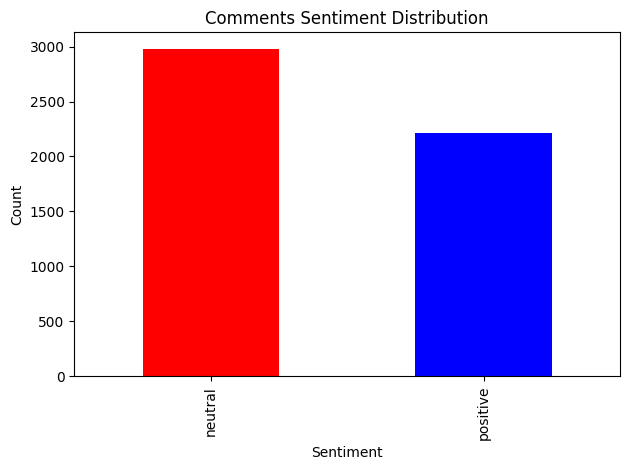

In [22]:
from matplotlib import pyplot as plt
counts = comments_df['sentiment'].value_counts()
print("Sentiment distribution:\n", counts)

plt.figure()
counts.sort_index().plot(kind='bar', color =['red','blue','green'])
plt.title('Comments Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

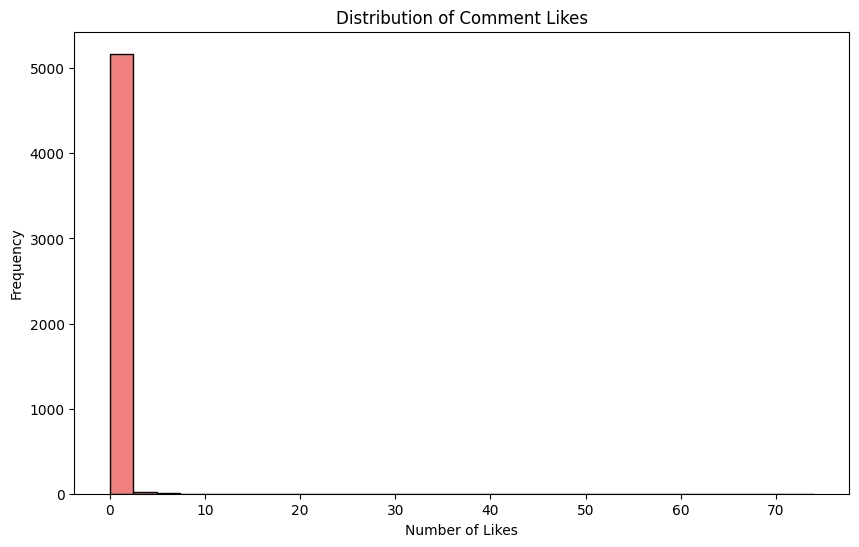


Summary Statistics for Comment Likes:
count    5197.000000
mean        0.221859
std         1.156466
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        74.000000
Name: likes, dtype: float64

Comments per Post Statistics:
count    755.000000
mean       6.883444
std        2.580210
min        1.000000
25%        5.000000
50%        7.000000
75%        9.000000
max       10.000000
dtype: float64


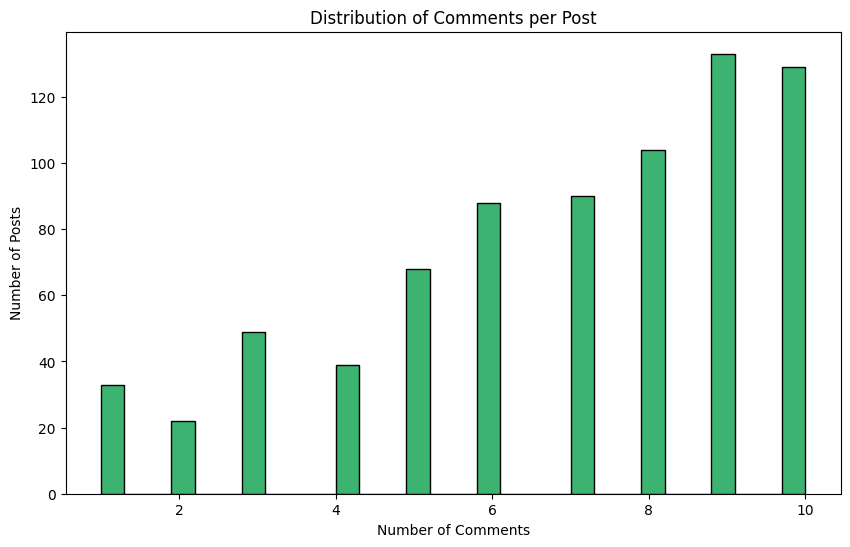


Interpretation:
1. Comment Likes Distribution:
   - Most comments receive few or no likes
   - The distribution is heavily right-skewed
   - Very few comments receive significant engagement

2. Comments per Post Distribution:
   - Most posts receive a moderate number of comments
   - Some posts generate significantly more discussion
   - The distribution shows variation in post engagement levels


In [23]:
# Plot distribution of comment likes
plt.figure(figsize=(10, 6))
plt.hist(comments_df['likes'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Comment Likes')
plt.xlabel('Number of Likes')
plt.ylabel('Frequency')
plt.show()

# Calculate and print summary statistics for comment likes
print("\nSummary Statistics for Comment Likes:")
print(comments_df['likes'].describe())

# Calculate comments per post
comments_per_post = comments_df.groupby('post_id').size()
print("\nComments per Post Statistics:")
print(comments_per_post.describe())

# Plot distribution of comments per post
plt.figure(figsize=(10, 6))
plt.hist(comments_per_post, bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Number of Posts')
plt.show()

# Print interpretation
print("\nInterpretation:")
print("1. Comment Likes Distribution:")
print("   - Most comments receive few or no likes")
print("   - The distribution is heavily right-skewed")
print("   - Very few comments receive significant engagement")

print("\n2. Comments per Post Distribution:")
print("   - Most posts receive a moderate number of comments")
print("   - Some posts generate significantly more discussion")
print("   - The distribution shows variation in post engagement levels")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23304\3837076771.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_posts = posts_df.groupby(posts_df['timestamp'].dt.to_period('M')).size()


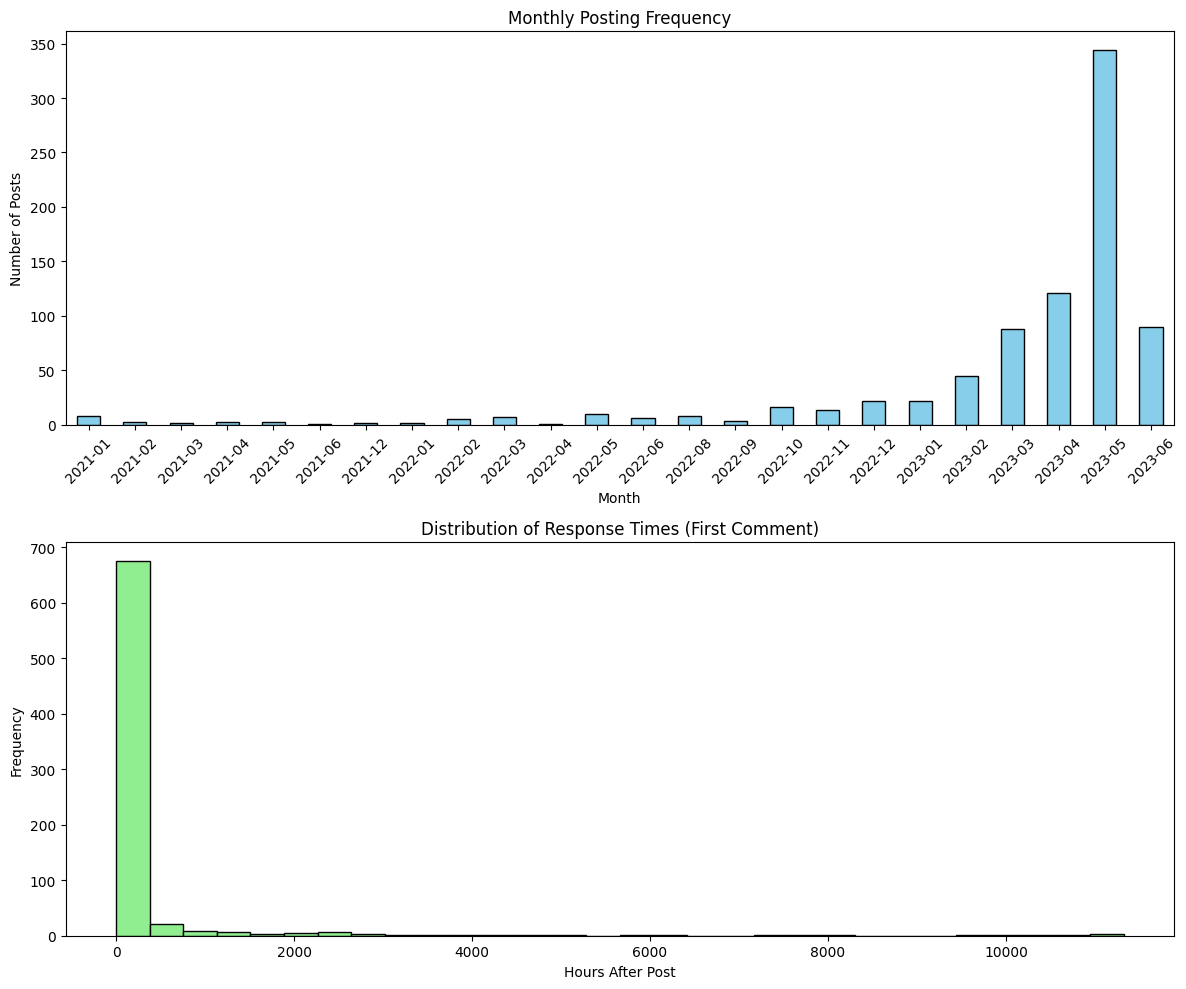


Temporal Analysis Summary:

1. Posting Frequency:
   - Total posts: 827
   - Average posts per month: 34.46
   - Most active month: 2023-05 with 344 posts

2. Response Time Analysis:
   - Average response time: 384.82 hours
   - Median response time: 29.25 hours
   - Minimum response time: 0.00 hours
   - Maximum response time: 11323.43 hours


In [24]:
# Convert timestamps to datetime if not already
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Posting frequency by month
monthly_posts = posts_df.groupby(posts_df['timestamp'].dt.to_period('M')).size()
monthly_posts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Monthly Posting Frequency')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Posts')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average response time (time between post and first comment)
# Calculate time difference between post and first comment for each post
response_times = []
for post_id in posts_df['post_id'].unique():
    post_time = posts_df[posts_df['post_id'] == post_id]['timestamp'].iloc[0]
    post_comments = comments_df[comments_df['post_id'] == post_id]
    if not post_comments.empty:
        first_comment_time = post_comments['timestamp'].min()
        response_time = (first_comment_time - post_time).total_seconds() / 3600  # Convert to hours
        response_times.append(response_time)

# Plot response time distribution
ax2.hist(response_times, bins=30, color='lightgreen', edgecolor='black')
ax2.set_title('Distribution of Response Times (First Comment)')
ax2.set_xlabel('Hours After Post')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTemporal Analysis Summary:")
print("\n1. Posting Frequency:")
print(f"   - Total posts: {len(posts_df)}")
print(f"   - Average posts per month: {monthly_posts.mean():.2f}")
print(f"   - Most active month: {monthly_posts.idxmax()} with {monthly_posts.max()} posts")

print("\n2. Response Time Analysis:")
print(f"   - Average response time: {np.mean(response_times):.2f} hours")
print(f"   - Median response time: {np.median(response_times):.2f} hours")
print(f"   - Minimum response time: {min(response_times):.2f} hours")
print(f"   - Maximum response time: {max(response_times):.2f} hours")


In [26]:
# Drop unnecessary columns likes, comments
comments_df = comments_df.drop(columns=['likes', 'comments'])
comments_df.head()

,post_id,commentUser,timestamp,clean_comment,polarity,sentiment
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,i have a proposal for u send me a dm please,0.2074,neutral
2,1,mariavmh,2023-06-04 16:46:34+00:00,smiling_face_with_heart eyes smiling_face_with...,0.8857,positive
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,red_heart red_heart red_heart,0.2744,neutral
4,1,jillviv,2023-06-04 15:06:03+00:00,smiling_face_with_heart eyes smiling_face_with...,0.9805,positive
5,1,sevdalaland,2023-06-04 08:39:28+00:00,fire fire fire,0.0278,neutral


In [33]:
def prepare_user_sequences(posts_df, comments_df):
    """
    Merge comments with posts and sort by timestamp to create temporal sequences.
    
    Args:
        posts_df: DataFrame with post information
        comments_df: DataFrame with user comments
    
    Returns:
        DataFrame with user interactions sorted by time
    """
    user_interactions = comments_df.merge(
        posts_df[['post_id']], 
        on='post_id', 
        how='left'
    )
    
    # Sort by timestamp to maintain temporal order
    user_interactions = user_interactions.sort_values('timestamp')
    
    return user_interactions

user_interactions = prepare_user_sequences(merged_df, comments_df)
print(f"Total user interactions: {len(user_interactions)}")
display(user_interactions.head())

Total user interactions: 5197


,post_id,commentUser,timestamp,clean_comment,polarity,sentiment
5170,822,alantrowe,2021-01-04 10:38:18+00:00,green_heart,0.2468,neutral
5171,823,alantrowe,2021-01-04 10:39:08+00:00,heart_suit,0.0711,neutral
5169,822,thedramatiara,2021-01-05 20:29:21+00:00,heart_with_arrow,-0.0089,neutral
5139,811,wellingthon_lessa,2021-01-08 17:24:27+00:00,amo esse desfile e olhe que assim que vi pela ...,-0.0477,neutral
5157,816,manzanidap,2021-01-08 18:20:58+00:00,esta apocalipsis es inquietante,-0.0225,neutral


In [34]:
import ast
def build_interaction_sequence(df):
    """
    Convert DataFrame rows to a list of interaction dictionaries.
    
    Args:
        df: DataFrame with columns [post_id, timestamp, polarity]
    
    Returns:
        List of interaction records
    """
    return df[['post_id', 'timestamp', 'polarity']].to_dict('records')

# Group by user and create sequences
# FIXED: Added include_groups=False to avoid deprecation warning
df_sequence = user_interactions.groupby('commentUser').apply(
    build_interaction_sequence,
    include_groups=False
).reset_index().rename(columns={0: 'interaction_sequence'})

# Extract post_id sequences
df_sequence["posts_sequence"] = df_sequence["interaction_sequence"].apply(
    lambda x: [item["post_id"] for item in x]
)

# Ensure posts_sequence is a list (not string)
def safe_parse(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

df_sequence['posts_sequence'] = df_sequence['posts_sequence'].apply(safe_parse)

# Filter: Keep only users with more than 2 interactions
df_sequence = df_sequence[df_sequence['posts_sequence'].apply(lambda x: len(x) > 2)]

print(f"Users with >2 interactions: {df_sequence.shape[0]}")
display(df_sequence.head())

Users with >2 interactions: 231


,commentUser,interaction_sequence,posts_sequence
30,92thestudio,"[{'post_id': 188, 'timestamp': 2023-05-17 14:5...","[188, 216, 91, 57]"
105,_surisingh,"[{'post_id': 369, 'timestamp': 2023-05-18 09:0...","[369, 361, 360]"
109,_vanessa.riedl,"[{'post_id': 246, 'timestamp': 2023-05-01 13:0...","[246, 88, 57]"
113,_yycc99,"[{'post_id': 69, 'timestamp': 2023-03-08 20:40...","[69, 64, 17]"
144,adrianericmorales,"[{'post_id': 795, 'timestamp': 2023-02-23 11:5...","[795, 797, 792]"


In [35]:
# Add sequence length column
df_sequence['sequence_length'] = df_sequence['posts_sequence'].apply(len)
df_sequence.head()

,commentUser,interaction_sequence,posts_sequence,sequence_length
30,92thestudio,"[{'post_id': 188, 'timestamp': 2023-05-17 14:5...","[188, 216, 91, 57]",4
105,_surisingh,"[{'post_id': 369, 'timestamp': 2023-05-18 09:0...","[369, 361, 360]",3
109,_vanessa.riedl,"[{'post_id': 246, 'timestamp': 2023-05-01 13:0...","[246, 88, 57]",3
113,_yycc99,"[{'post_id': 69, 'timestamp': 2023-03-08 20:40...","[69, 64, 17]",3
144,adrianericmorales,"[{'post_id': 795, 'timestamp': 2023-02-23 11:5...","[795, 797, 792]",3


In [ ]:
merged_df.to_csv()

In [37]:
#comments_df.to_csv('comments_df.csv', index=False)
merged_df.to_csv(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\input\content.csv", index=False)
df_sequence.to_csv(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\input\user_behavior.csv", index=False)

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Multimodal Feature Encoding </div>

## Architecture Overview
- **Image Features**: Florence-2 image descriptions → BERT encoding
- **Text Features**: Caption, Hashtags, Mentions → BERT encoding  
- **Final Output**: Concatenated multimodal embeddings for each post

In [ ]:
# === Import Libraries for Multimodal Encoding ===
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
from tqdm import tqdm

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load BERT model for text encoding
BERT_MODEL = "bert-base-uncased"
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
bert_model = BertModel.from_pretrained(BERT_MODEL).to(device)
bert_model.eval()

print(f"BERT model loaded: {BERT_MODEL}")
print(f"BERT embedding dimension: {bert_model.config.hidden_size}")

In [ ]:
# === BERT Encoding Functions ===

def encode_text_batch(texts: list, tokenizer, model, batch_size=32, max_length=128):
    """
    Encode a batch of texts using BERT [CLS] token embedding.
    
    Args:
        texts: List of text strings
        tokenizer: BERT tokenizer
        model: BERT model
        batch_size: Batch size for processing
        max_length: Maximum sequence length
    
    Returns:
        numpy array of shape (num_texts, hidden_size)
    """
    embeddings = []
    
    # Clean texts - replace empty/NaN with placeholder
    cleaned_texts = []
    for t in texts:
        if pd.isna(t) or str(t).strip() == "" or str(t).strip() == "no_hashtag" or str(t).strip() == "no_mention":
            cleaned_texts.append("[PAD]")  # Use PAD token for empty text
        else:
            cleaned_texts.append(str(t).strip())
    
    for i in tqdm(range(0, len(cleaned_texts), batch_size), desc="Encoding"):
        batch = cleaned_texts[i:i + batch_size]
        
        # Tokenize
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            # Use [CLS] token embedding (first token)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
    
    return np.vstack(embeddings)


def encode_multimodal_features(df, tokenizer, model, batch_size=32):
    """
    Encode multimodal features for each post.
    
    Features encoded:
    - image_description (Florence-2 output) → BERT embedding
    - caption → BERT embedding  
    - hashtags → BERT embedding
    - mentions → BERT embedding
    
    Returns:
        Dictionary with individual embeddings and concatenated multimodal embedding
    """
    print("=" * 60)
    print("MULTIMODAL FEATURE ENCODING")
    print("=" * 60)
    
    # 1. Encode Image Descriptions (from Florence-2)
    print("\n[1/4] Encoding Image Descriptions (Florence-2 → BERT)...")
    image_embeddings = encode_text_batch(
        df['image_description'].tolist(),
        tokenizer, model, batch_size
    )
    print(f"    Shape: {image_embeddings.shape}")
    
    # 2. Encode Captions
    print("\n[2/4] Encoding Captions...")
    caption_embeddings = encode_text_batch(
        df['caption'].tolist(),
        tokenizer, model, batch_size
    )
    print(f"    Shape: {caption_embeddings.shape}")
    
    # 3. Encode Hashtags
    print("\n[3/4] Encoding Hashtags...")
    hashtag_embeddings = encode_text_batch(
        df['hashtags'].tolist(),
        tokenizer, model, batch_size
    )
    print(f"    Shape: {hashtag_embeddings.shape}")
    
    # 4. Encode Mentions
    print("\n[4/4] Encoding Mentions...")
    mention_embeddings = encode_text_batch(
        df['mentions'].tolist(),
        tokenizer, model, batch_size
    )
    print(f"    Shape: {mention_embeddings.shape}")
    
    # Concatenate all embeddings
    print("\n" + "=" * 60)
    print("CONCATENATING MULTIMODAL EMBEDDINGS")
    print("=" * 60)
    
    multimodal_embeddings = np.concatenate([
        image_embeddings,    # 768-dim
        caption_embeddings,  # 768-dim
        hashtag_embeddings,  # 768-dim
        mention_embeddings   # 768-dim
    ], axis=1)
    
    print(f"\nFinal multimodal embedding shape: {multimodal_embeddings.shape}")
    print(f"  - Image (Florence-2): {image_embeddings.shape[1]} dims")
    print(f"  - Caption: {caption_embeddings.shape[1]} dims")
    print(f"  - Hashtags: {hashtag_embeddings.shape[1]} dims")
    print(f"  - Mentions: {mention_embeddings.shape[1]} dims")
    print(f"  - Total: {multimodal_embeddings.shape[1]} dims")
    
    return {
        'image': image_embeddings,
        'caption': caption_embeddings,
        'hashtags': hashtag_embeddings,
        'mentions': mention_embeddings,
        'multimodal': multimodal_embeddings
    }

In [ ]:
# === Run Multimodal Feature Encoding ===

# Handle missing image descriptions
merged_df['image_description'] = merged_df['image_description'].fillna("")

# Encode all features
embeddings = encode_multimodal_features(
    merged_df, 
    bert_tokenizer, 
    bert_model, 
    batch_size=32
)

print("\n✓ Multimodal encoding completed!")

## Embedding Visualization

In [ ]:
# === Visualize Embedding Statistics ===
from matplotlib import pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Image embedding distribution
ax1 = axes[0, 0]
ax1.hist(embeddings['image'].flatten(), bins=50, color='coral', alpha=0.7, edgecolor='black')
ax1.set_title('Image Embedding Distribution (Florence-2 → BERT)')
ax1.set_xlabel('Embedding Value')
ax1.set_ylabel('Frequency')

# Plot 2: Caption embedding distribution
ax2 = axes[0, 1]
ax2.hist(embeddings['caption'].flatten(), bins=50, color='skyblue', alpha=0.7, edgecolor='black')
ax2.set_title('Caption Embedding Distribution')
ax2.set_xlabel('Embedding Value')
ax2.set_ylabel('Frequency')

# Plot 3: Hashtag embedding distribution
ax3 = axes[1, 0]
ax3.hist(embeddings['hashtags'].flatten(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
ax3.set_title('Hashtag Embedding Distribution')
ax3.set_xlabel('Embedding Value')
ax3.set_ylabel('Frequency')

# Plot 4: Mention embedding distribution
ax4 = axes[1, 1]
ax4.hist(embeddings['mentions'].flatten(), bins=50, color='plum', alpha=0.7, edgecolor='black')
ax4.set_title('Mention Embedding Distribution')
ax4.set_xlabel('Embedding Value')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\images\embedding_distributions.png", dpi=150)
plt.show()

# Print statistics
print("\n=== EMBEDDING STATISTICS ===")
for name, emb in embeddings.items():
    print(f"\n{name.upper()}:")
    print(f"  Shape: {emb.shape}")
    print(f"  Mean: {emb.mean():.6f}")
    print(f"  Std: {emb.std():.6f}")
    print(f"  Min: {emb.min():.6f}")
    print(f"  Max: {emb.max():.6f}")

## Save Embeddings

In [ ]:
# === Save Embeddings ===
import os

# Create output directory
output_dir = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\input"
os.makedirs(output_dir, exist_ok=True)

# Save individual embeddings
np.save(os.path.join(output_dir, "image_embeddings.npy"), embeddings['image'])
np.save(os.path.join(output_dir, "caption_embeddings.npy"), embeddings['caption'])
np.save(os.path.join(output_dir, "hashtag_embeddings.npy"), embeddings['hashtags'])
np.save(os.path.join(output_dir, "mention_embeddings.npy"), embeddings['mentions'])

# Save concatenated multimodal embeddings
np.save(os.path.join(output_dir, "multimodal_embeddings.npy"), embeddings['multimodal'])

# Create post_id to embedding index mapping
post_id_mapping = merged_df[['post_id']].reset_index(drop=True)
post_id_mapping.to_csv(os.path.join(output_dir, "post_embedding_mapping.csv"), index=True)

print("✓ Saved embeddings:")
print(f"  - image_embeddings.npy: {embeddings['image'].shape}")
print(f"  - caption_embeddings.npy: {embeddings['caption'].shape}")
print(f"  - hashtag_embeddings.npy: {embeddings['hashtags'].shape}")
print(f"  - mention_embeddings.npy: {embeddings['mentions'].shape}")
print(f"  - multimodal_embeddings.npy: {embeddings['multimodal'].shape}")
print(f"  - post_embedding_mapping.csv: {len(post_id_mapping)} posts")

## Embedding Space Visualization (t-SNE)

In [ ]:
# === t-SNE Visualization of Multimodal Embeddings ===
from sklearn.manifold import TSNE

print("Running t-SNE on multimodal embeddings...")
print("This may take a few minutes...")

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings['multimodal'])

# Create visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Color by user (top 10 users)
top_users = merged_df['postUser'].value_counts().head(10).index.tolist()
colors = []
for user in merged_df['postUser']:
    if user in top_users:
        colors.append(top_users.index(user))
    else:
        colors.append(-1)

scatter = ax.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=colors, 
    cmap='tab10', 
    alpha=0.6, 
    s=50
)

ax.set_title('t-SNE Visualization of Multimodal Embeddings\n(Colored by Top 10 Users)', fontsize=14)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')

# Add legend for top users
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=plt.cm.tab10(i/10), 
                              markersize=10, label=user) 
                   for i, user in enumerate(top_users)]
ax.legend(handles=legend_elements, loc='upper right', title='Top Users')

plt.tight_layout()
plt.savefig(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\images\tsne_multimodal_embeddings.png", dpi=150)
plt.show()

print("\n✓ t-SNE visualization completed!")

In [ ]:
# === Summary ===
print("=" * 70)
print("MULTIMODAL FEATURE ENCODING - SUMMARY")
print("=" * 70)
print(f"""
Architecture:
  - Florence-2: Used for generating image descriptions (already processed)
  - BERT (bert-base-uncased): Used for encoding all text features
  
Features Encoded:
  1. Image Description (from Florence-2) → 768-dim BERT embedding
  2. Caption Text                        → 768-dim BERT embedding
  3. Hashtags                            → 768-dim BERT embedding
  4. Mentions                            → 768-dim BERT embedding
  
Final Output:
  - Concatenated Multimodal Embedding: {embeddings['multimodal'].shape[1]} dimensions
  - Total Posts Encoded: {embeddings['multimodal'].shape[0]}
  
Files Saved:
  - input/image_embeddings.npy
  - input/caption_embeddings.npy
  - input/hashtag_embeddings.npy
  - input/mention_embeddings.npy
  - input/multimodal_embeddings.npy
  - input/post_embedding_mapping.csv
  - images/embedding_distributions.png
  - images/tsne_multimodal_embeddings.png
""")
print("=" * 70)